In [1]:
import numpy as np
import matplotlib.pyplot as plt
import opt_einsum as oe
import scipy.sparse as sp
from mpl_toolkits.mplot3d import Axes3D

from quant_rotor.core.dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state

from quant_rotor.models.dense.support_ham import write_matrix_elements, m_to_p, basis_m_to_p_matrix_conversion
from quant_rotor.models.dense.density_matrix import density_matrix_1, density_matrix_trans

from quant_rotor.core.dense.hamiltonian import hamiltonian_dense
from quant_rotor.core.dense.hamiltonian_big import hamiltonian_general_dense, hamiltonian_big_dense
from quant_rotor.core.sparse.hamiltonian_big import hamiltonian_general_sparse, hamiltonian_big_sparse
from quant_rotor.core.sparse.hamiltonian import hamiltonian_sparse

from quant_rotor.core.dense.t_amplitudes_periodic_fast import t_periodic

from quant_rotor.core.dense.de_solve_one_thermal import integration_scheme
from quant_rotor.core.dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast

np.set_printoptions(suppress = True, linewidth = 1500, threshold = np.inf, precision = 12)

In [ ]:
site = 3
state = 9
state_NO = 5
final = 100

g = 0.2

In [15]:
def sites_CCC_func(site):

    _, energy, _, _ = integration_scheme(site, 11, g, t_init=0, t_final=100, nof_points=100000)

    return energy[-1].real

In [16]:
def sites_NO_func(site):

    H_NO, _, _ = hamiltonian_general_sparse(state, state_NO, site, g)
    print("Ham_Done")
    eig_val_NO, _ = sp.linalg.eigsh(H_NO, k=5, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val_NO)

In [17]:
def sites_ED_func(site):

    H, _, _ = hamiltonian_sparse(state, site, g)

    eig_val, _ = sp.linalg.eigsh(H, k=1, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val)

In [ ]:
n_CCC = 30
n_ED = 8
n_NO = 11

E_ED = np.zeros((n_ED))
E_NO = np.zeros((n_NO))
E_CCC = np.zeros((n_CCC))

sites_CCC = np.zeros((n_CCC))
sites_ED = np.zeros((n_ED))
sites_NO = np.zeros((n_NO))

In [8]:
for i in range(3, n_ED):

    E_ED[i - 3] = sites_ED_func(i)

    sites_ED[i-3] = i
    print(E_ED[i-3], sites_ED[i-3])

Finished site 0
Finished site 1
Finished site 2
-0.08587043888364759 3.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.1051692655128193 4.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
-0.12772411036754058 5.0
Finished site 0
Finished site 1


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_89375/961205076.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  E_ED[i - 3] = sites_ED_func(i)


Finished site 2
Finished site 3
Finished site 4
Finished site 5
-0.15218930200930866 6.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 5
Finished site 6
-0.17715633332420402 7.0


In [ ]:
for i in range(3, n_CCC):

    E_CCC[i - 3] = sites_CCC_func(i)

    sites_CCC[i-3] = i
    print(E_CCC[i-3], sites_CCC[i-3])

-0.08793411470868667 3.0
-0.10783443349972918 4.0
-0.1306681226495107 5.0
-0.1555131175183597 6.0
-0.18091707548387057 7.0
-0.20656931131393955 8.0
-0.2323130022248852 9.0
-0.2580946139779799 10.0
-0.2838914328270877 11.0
-0.3096945528694664 12.0
-0.3355002785395787 13.0
-0.36130709406556544 14.0
-0.38711436689079326 15.0
-0.41292183265733934 16.0
-0.4387293800964248 17.0
-0.464536962226413 18.0
-0.4903445591308087 19.0
-0.5161521623428728 20.0
-0.5419597682535056 21.0
-0.5677673753208173 22.0
-0.5935749828847356 23.0
-0.6193825906621809 24.0
-0.645190198531564 25.0
-0.6709978064405776 26.0


In [ ]:
plt.plot(x_bigger_basis, np.log10(y_bigger_basis), label=f"#Basis size before truncation = {31}, NO = {state_NO}")
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B /> 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()
plt.show()

# Graph #2

In [31]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = site

    g = 1
    D_val = 1 * 10**(-num)

    if site_i == 2:
        periodic = False
    else:
        periodic = True

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    E_CC = np.abs(energy[-1].real)
    E_ED = np.abs(np.min(eig_val_loc).real)

    per_diff = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200

    print(E_CC.real, E_ED.real)

    return (np.log10(D_val)).real, per_diff

In [32]:
site = 2
state = 11
state_NO = 5
final = 400

In [33]:
n = 15
x = np.zeros((n))
y = np.zeros((n))

for i in range(n):
    x[i], y[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x[i], y[i])

ED done.
0.36318830298424654 0.5129981200262083
0.0 34.19587729452278
ED done.
1.4183415926247283 1.415356791394682
-1.0 0.21066470919268737
ED done.
1.7915464437040594 1.7913841586077273
-2.0 0.0090587909365246
ED done.
1.864170598252051 1.8641687564980147
-3.0 9.879755359837557e-05
ED done.
1.8723823093998875 1.8723822960783498
-4.0 7.114753024144519e-07
ED done.
1.8732144694443462 1.8732144698721371
-5.0 2.283726293668918e-08
ED done.
1.8732977970513474 1.8732977971117815
-6.0 3.2260808858688562e-09
ED done.
1.8733061309298114 1.8733061309360313
-7.0 3.320286722204027e-10
ED done.
1.8733069643288385 1.873306964329462
-8.0 3.328345340630119e-11
ED done.
1.8733070476688543 1.8733070476689155
-9.0 3.2714504029422148e-12
ED done.
1.8733070560028593 1.873307056002866
-10.0 3.5559243352045325e-13
ED done.
1.8733070568362566 1.873307056836258
-11.0 7.111848667245154e-14
ED done.
1.8733070569195982 1.873307056919598
-12.0 1.185308111154793e-14
ED done.
1.8733070569279315 1.873307056927931
-

In [34]:
site = 2
state = 21
state_NO = 5
final = 400

In [35]:
x_bigger_basis = np.zeros((n))
y_bigger_basis = np.zeros((n))

for i in range(n):
    x_bigger_basis[i], y_bigger_basis[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x_bigger_basis[i], y_bigger_basis[i])

ED done.
0.3631883029431415 0.5129981196637204
0.0 34.19587723691478
ED done.
1.4184233538348412 1.41539738152528
-1.0 0.21356130765812908
ED done.
1.8101878039844657 1.809345151573959
-2.0 0.046561389044003546
ED done.
1.934365838630262 1.9343186584246572
-3.0 0.0024390826204983866
ED done.
1.958613621704378 1.9586130715959311
-4.0 2.8086628110443985e-05
ED done.
1.961371405493912 1.9613714017232793
-5.0 1.9224470633296127e-07
ED done.
1.9616510704763548 1.9616510706283865
-6.0 7.750191806706476e-09
ED done.
1.9616790764734826 1.9616790764939958
-7.0 1.0456933033897915e-09
ED done.
1.96168187746882 1.9616818774709248
-8.0 1.0729368682342311e-10
ED done.
1.9616821575723122 1.9616821575725227
-9.0 1.0730499059512343e-11
ED done.
1.9616821855827031 1.9616821855827242
-10.0 1.075313708964124e-12
ED done.
1.9616821883837385 1.9616821883837403
-11.0 9.055273325715511e-14
ED done.
1.9616821886638407 1.9616821886638414
-12.0 3.395727496658453e-14
ED done.
1.961682188691849 1.9616821886918494


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_94171/2236822133.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(x_bigger_basis, np.log10(y_bigger_basis), label=f"#Basis size before truncation = {11}, NO = {state_NO}")
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_94171/2236822133.py:10: RuntimeWarning: divide by zero encountered in log10
  y0 = np.log10(y_bigger_basis)[0]


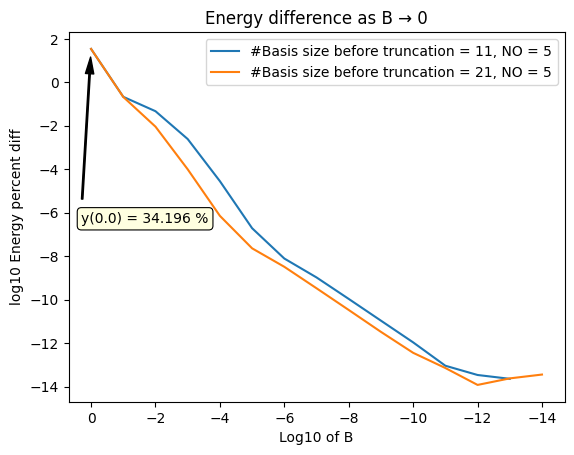

In [52]:
plt.plot(x_bigger_basis, np.log10(y_bigger_basis), label=f"#Basis size before truncation = {11}, NO = {state_NO}")
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()

x0 = x_bigger_basis[0]
y0 = np.log10(y_bigger_basis)[0]

plt.annotate(
    f"y({x_bigger_basis[0]}) = {y_bigger_basis[0]:.3f} %",
    xy=(x0, y0),                  # point to (x=0, y=y0)
    xytext=(0.3, y0 -8),      # position of text box
    textcoords='data',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
    fontsize=10
)
plt.show()

In [50]:
y_bigger_basis

array([34.195877236915,  0.213561307658,  0.046561389044,  0.00243908262 ,  0.000028086628,  0.000000192245,  0.00000000775 ,  0.000000001046,  0.000000000107,  0.000000000011,  0.000000000001,  0.            ,  0.            ,  0.            ,  0.            ])

# Graph 3

In [2]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = 4

    g = 1
    D_val = 1 * 10**(-num)

    periodic = False

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    periodic = True

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max, _ = t_periodic(site_i, state_NO, 1, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    indecies = np.argsort(eig_val_loc)

    E_CC = np.abs(energy[-1].real)
    E_ED = np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real) / 2

    per_diff_1 = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200
    per_diff_2 = (np.abs(E_CC - np.abs(eig_val_loc[indecies[0]].real)) / (E_CC + np.abs(eig_val_loc[indecies[0]].real))) * 200

    print(E_CC.real, E_ED.real)

    return (np.log10(D_val)).real, per_diff_1, per_diff_2

In [3]:
site = 2
state = 11
state_NO = 5
final = 200

In [4]:
calculate_xy_no_field(site, state, state_NO, final, 0)

ED done.


TypeError: t_periodic() missing 1 required positional argument: 'fast'

In [ ]:
n = 5
x_1 = np.zeros((n))
y_2_1 = np.zeros((n))
y_1_1 = np.zeros((n))

for i in range(n):
    x_1[i], y_1_1[i], y_2_1[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x_1[i], y_1_1[i], y_2_1[i])

ED done.
3.01880110464208 2.9611214795142646
0.0 1.9291094262870985 1.141552538250456
ED done.
6.28876174475285 5.98319588094168
0.0 4.979904154352495 0.03423170971030941
ED done.
7.302845077228885 7.1478560260585855
0.0 2.145073101471046 0.0010231273381131176
ED done.
7.459754184868391 7.320800461879102
0.0 1.8802233922915195 0.0009785765661167838
ED done.
7.4764530224447565 7.338851035471418
0.0 1.8575654800660621 0.001234690245315325


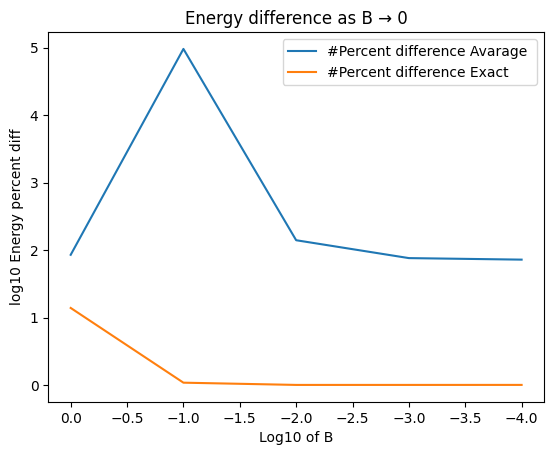

In [28]:
plt.plot((x[:5]), y_1_1, label=f"#Percent difference Avarage ")
plt.plot((x[:5]), y_2_1, label=f"#Percent difference Exact")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()

# x0 = x[0]
# y0 = np.log10(y_bigger_basis)[0]

# plt.annotate(
#     f"y({x_bigger_basis[0]}) = {y_bigger_basis[0]:.3f} %",
#     xy=(x0, y0),                  # point to (x=0, y=y0)
#     xytext=(0.3, y0 -8),      # position of text box
#     textcoords='data',
#     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
#     bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
#     fontsize=10
# )
plt.show()

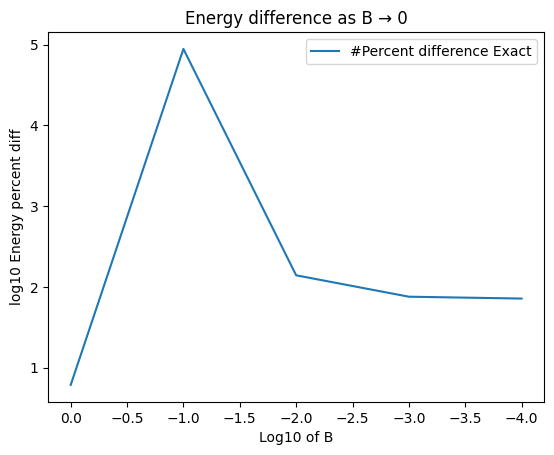

In [ ]:
plt.plot((x), y_1_1 - y_2_1, label=f"#Percent difference Exact")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()

In [ ]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = 4

    g = num
    D_val = 1

    periodic = False

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    periodic = True

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    indecies = np.argsort(eig_val_loc)

    E_CC = np.abs(energy[-1].real)
    E_ED = np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real) / 2

    per_diff_1 = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200
    per_diff_2 = (np.abs(E_CC - np.abs(eig_val_loc[indecies[0]].real)) / (E_CC + np.abs(eig_val_loc[indecies[0]].real))) * 200

    print(E_CC.real, E_ED.real)

    return (np.log10(D_val)).real, per_diff_1, per_diff_2

In [20]:
n = 10
x = np.zeros((n))
y_2 = np.zeros((n))
y_1 = np.zeros((n))

for i in range(n):
    x[i], y_1[i], y_2[i] = calculate_xy_no_field(site, state, state_NO, final, i/10)
    print(x[i], y_1[i], y_2[i])

ED done.
3.01880110464208 2.9611214795142646
0.0 1.9291094262870985 1.141552538250456
ED done.
3.4910519466673677 3.4421156887845967
-0.1 1.4116565603445392 0.748486312087077
ED done.
3.9252252507500325 3.880282525936938
-0.2 1.1515644106415976 0.46279013167232685
ED done.
4.3218585956725875 4.271116953008014
-0.30000000000000004 1.1810028406833892 0.2834817608393899
ED done.
4.6834145712164394 4.607317133989989
-0.4000000000000001 1.6381365782806159 0.17627004745647856
ED done.
5.013410212419395 4.8812958431491245
-0.5 2.6704051343884005 0.1132373982333834
ED done.
5.315542647386033 5.103224069836809
-0.6 4.075695009050332 0.07614066411735608
ED done.
5.592487852231216 5.319923396313937
-0.7 4.995494574191686 0.05458173001496246
ED done.
5.864168155524752 5.48558203704107
-0.8 6.671267861589744 0.04089419535129039
ED done.
6.087940693884089 5.747638799512346
-0.9 5.750489776383348 0.03676022373808553


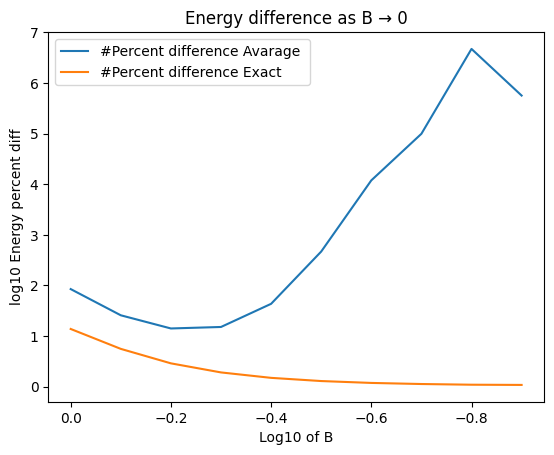

In [ ]:
plt.plot((x), y_1, label=f"#Percent difference Avarage ")
plt.plot((x), y_2, label=f"#Percent difference Exact")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("g")
plt.ylabel("log10 Energy percent diff")
plt.legend()

# x0 = x[0]
# y0 = np.log10(y_bigger_basis)[0]

# plt.annotate(
#     f"y({x_bigger_basis[0]}) = {y_bigger_basis[0]:.3f} %",
#     xy=(x0, y0),                  # point to (x=0, y=y0)
#     xytext=(0.3, y0 -8),      # position of text box
#     textcoords='data',
#     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
#     bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
#     fontsize=10
# )
plt.show()